# Pipeline de Decisión — Caso 3

**Notebook de desarrollo interactivo:** contiene el código fuente del pipeline inline,
permite probar casos individuales o en lote, con flags para controlar sobreescritura
y persistencia en BD.

## Flujo del pipeline

```
load_case → compute_features → apply_rules
                                    │
                        ┌───────────┼───────────┐
                        ▼           ▼           ▼
                    RECHAZAR    APROBAR     ambiguo
                        │           │           │
                        ▼           ▼     llm_classify
                   final_decision   │           │
                        │           │     final_decision
                        ▼           ▼           │
                   generate_output ◄────────────┘
                        │
                       END
```

## Flags configurables

| Flag | Default | Descripción |
|------|---------|-------------|
| `OVERWRITE` | `False` | Si `True`, reprocesa casos ya analizados |
| `SAVE_TO_DB` | `True` | Si `True`, persiste resultados en PostgreSQL |
| `USE_DB_RULES` | `True` | Si `True`, usa reglas de DB; si `False`, YAML |
| `SHOW_LLM_DETAIL` | `True` | Mostrar análisis estructurado del LLM en output |

> **Diferencia con `07_pipeline_test.ipynb`:** esta notebook contiene el código
> fuente del pipeline inline (editable en caliente), controles de sobreescritura,
> y ejecución batch interactiva. La 07 es solo demo con resultados pre-computados.

In [1]:
import os
import sys
import json
import re
import time
from pathlib import Path
from typing import Any, TypedDict

from dotenv import load_dotenv

try:
    CWD = Path.cwd()
except OSError:
    CWD = Path(".").resolve()
PROYECTO = CWD.parent if CWD.name == "notebooks" else CWD
if str(PROYECTO) not in sys.path:
    sys.path.insert(0, str(PROYECTO))
try:
    os.chdir(str(PROYECTO))
except OSError:
    pass

load_dotenv(PROYECTO / ".env")

import pandas as pd
import psycopg2
import psycopg2.extras
import yaml
from langgraph.graph import END, StateGraph

# ── Flags interactivos (modificar aquí) ──────────────────────────
OVERWRITE = True        # True: reprocesa casos ya analizados
SAVE_TO_DB = True        # True: persiste en PostgreSQL
USE_DB_RULES = True      # True: reglas de DB; False: YAML fallback
SHOW_LLM_DETAIL = True   # mostrar análisis LLM en output

# ── Conexión DB ─────────────────────────────────────────────────
DB_CONFIG = {
    'host': os.getenv('DB_HOST', 'localhost'),
    'port': int(os.getenv('DB_PORT', '5432')),
    'dbname': os.getenv('DB_NAME', 'rappi_cases'),
    'user': os.getenv('DB_USER', 'rappi'),
    'password': os.getenv('DB_PASSWORD', 'rappi_pass'),
}

def db_conectar():
    return psycopg2.connect(**DB_CONFIG)

# Verificar conexión
try:
    conn = db_conectar()
    with conn.cursor() as cur:
        cur.execute("SELECT COUNT(*) FROM casos")
        total_casos = cur.fetchone()[0]
    conn.close()
    print(f'[OK] Setup completo — {total_casos} casos en DB')
except Exception as e:
    print(f'[WARN] DB no disponible: {e}')
    print('[INFO] SAVE_TO_DB se forzará a False')
    SAVE_TO_DB = False

[OK] Setup completo — 250 casos en DB


## Pipeline: State + Nodos 1-2 (load_case, compute_features)

El estado `CaseState` viaja entre nodos del grafo. `load_case` carga desde
PostgreSQL; `compute_features` calcula las 16 features o usa las precalculadas.

In [ ]:
# ── State ─────────────────────────────────────────────────────────
class CaseState(TypedDict, total=False):
    case_id: str
    raw_data: dict[str, Any]
    features: dict[str, Any]
    rule_result: str | None
    decision_regla: str | None           # APROBAR | RECHAZAR | AMBIGUO | ESCALAR
    decision_llm: str | None             # veredicto discreto del LLM
    justificacion_regla: str             # descripción de reglas disparadas
    justificacion_llm: str | None
    senales_regla: list[str]             # "campo operador umbral = valor real"
    senales_llm: list[str]
    rule_details: list[dict[str, Any]]
    llm_analysis: dict[str, Any] | None
    llm_resultado: dict[str, Any] | None
    final_decision: str
    justification: str                   # derivado para API/UI
    rule_disparada: str
    es_sintetico: bool

# ── Nodo 1: load_case ────────────────────────────────────────────
def load_case(state: CaseState) -> CaseState:
    """Carga los datos crudos del caso desde PostgreSQL."""
    conn = db_conectar()
    try:
        with conn.cursor() as cur:
            cur.execute(
                """SELECT caso_id, usuario_id, antiguedad_usuario_dias, ciudad,
                          vertical, restaurante, valor_orden_mxn,
                          compensacion_solicitada_mxn, num_compensaciones_90d,
                          monto_compensado_90d_mxn, entrega_confirmada_gps,
                          tiempo_entrega_real_min, flags_fraude_previos,
                          motivo_reclamo, descripcion_reclamo,
                          recomendacion_agente, es_sintetico,
                          comp_ratio, burn_rate, freq_densidad,
                          flag_inconsistencia_gps, flag_mentira_gps_alta,
                          flag_retraso_critico, flag_account_abuse,
                          score_riesgo_previo, longitud_reclamo,
                          flag_palabras_criticas, riesgo_ciudad,
                          riesgo_vertical, gps_paradoja_score,
                          sospecha_nuevo_recurrente, ratio_deviation
                   FROM cases WHERE caso_id = %s""",
                (state["case_id"],),
            )
            row = cur.fetchone()
            if row is None:
                raise ValueError(f"Caso {state['case_id']} no encontrado")
            cols = [desc[0] for desc in cur.description]
            raw = dict(zip(cols, row))
    finally:
        conn.close()
    state["raw_data"] = raw
    state["es_sintetico"] = bool(raw.get("es_sintetico", False))
    return state

# ── Nodo 2: compute_features ─────────────────────────────────────
PALABRAS_CRITICAS_RE = re.compile(
    r"alergi|intoxic|polic[ií]a|sangre|insult|denunci|abogado|demanda|hospital|veneno",
    re.IGNORECASE,
)

def _cargar_percentiles() -> dict[str, float]:
    df = pd.read_parquet(PROYECTO / "data" / "casos_con_features.parquet")
    return {
        "p90_tiempo": float(df["tiempo_entrega_real_min"].quantile(0.90)),
        "p95_comp": float(df["compensacion_solicitada_mxn"].quantile(0.95)),
        "p95_ncomps": float(df["num_compensaciones_90d"].quantile(0.95)),
        "p90_ncomps": float(df["num_compensaciones_90d"].quantile(0.90)),
    }

def compute_features(state: CaseState) -> CaseState:
    """Calcula las 16 features a partir de raw_data.
    Si raw_data ya tiene features (vino de DB), las usa directamente."""
    raw = state["raw_data"]
    if raw.get("comp_ratio") is not None:
        state["features"] = raw
        return state
    p = _cargar_percentiles()
    features = dict(raw)
    valor = max(float(raw.get("valor_orden_mxn", 0)), 1.0)
    features["comp_ratio"] = float(raw.get("compensacion_solicitada_mxn", 0)) / valor
    features["burn_rate"] = float(raw.get("monto_compensado_90d_mxn", 0)) / max(float(raw.get("antiguedad_usuario_dias", 0)), 1.0)
    features["freq_densidad"] = float(raw.get("num_compensaciones_90d", 0)) / min(max(float(raw.get("antiguedad_usuario_dias", 0)), 1.0), 90.0)
    features["flag_inconsistencia_gps"] = raw.get("motivo_reclamo") == "Orden no llegó" and raw.get("entrega_confirmada_gps") in ("SÍ - confirmada", "Parcial")
    features["flag_mentira_gps_alta"] = raw.get("motivo_reclamo") in ("Producto incorrecto", "Producto incompleto") and raw.get("entrega_confirmada_gps") == "SÍ - confirmada" and float(raw.get("compensacion_solicitada_mxn", 0)) > p["p95_comp"]
    features["flag_retraso_critico"] = float(raw.get("tiempo_entrega_real_min", 0)) > p["p90_tiempo"]
    features["flag_account_abuse"] = float(raw.get("antiguedad_usuario_dias", 0)) < 90 and float(raw.get("num_compensaciones_90d", 0)) > p["p95_ncomps"]
    features["score_riesgo_previo"] = float(raw.get("flags_fraude_previos", 0)) * 2 + float(raw.get("num_compensaciones_90d", 0)) * 0.5
    texto = str(raw.get("descripcion_reclamo", ""))
    features["longitud_reclamo"] = len(texto.split())
    features["flag_palabras_criticas"] = bool(PALABRAS_CRITICAS_RE.search(texto))
    df_ref = pd.read_parquet(PROYECTO / "data" / "casos_con_features.parquet")
    features["riesgo_ciudad"] = float((df_ref["ciudad"] == raw.get("ciudad", "")).mean())
    features["riesgo_vertical"] = float((df_ref["vertical"] == raw.get("vertical", "")).mean())
    gps_ok = raw.get("entrega_confirmada_gps") == "SÍ - confirmada"
    features["gps_paradoja_score"] = (0.5 if gps_ok else 0.0) + (0.3 if float(raw.get("num_compensaciones_90d", 0)) > p["p90_ncomps"] else 0.0) + (0.2 if float(raw.get("flags_fraude_previos", 0)) > 0 else 0.0)
    features["sospecha_nuevo_recurrente"] = float(raw.get("antiguedad_usuario_dias", 0)) < 90 and float(raw.get("num_compensaciones_90d", 0)) >= 3 and float(raw.get("flags_fraude_previos", 0)) >= 1
    media = float(df_ref["comp_ratio"].mean())
    std = float(df_ref["comp_ratio"].std())
    features["ratio_deviation"] = (features["comp_ratio"] - media) / std if std > 0 else 0.0
    state["features"] = features
    return state

print('[OK] State + load_case + compute_features definidos')


## Pipeline: Nodo 3 — apply_rules

Evalúa el caso contra reglas activas. Si `USE_DB_RULES=True` usa el motor
genérico (reglas versionadas en DB). Si no, usa el motor YAML (fallback).

**Precedencia:** ESCALAR_FORZOSO → RECHAZAR → APROBAR → AMBIGUO

In [ ]:
from src.rules import repository
from src.rules.generic_engine import GenericRuleEngine
from src.rules.rule_engine import RuleEngine
from src.rules.signals import senal_de_regla, formato_senal_regla

def _aplicar_generico(state: CaseState) -> CaseState:
    """Evalúa con motor genérico (reglas versionadas en DB)."""
    features = state["features"]
    engine = GenericRuleEngine(repository.cargar_reglas_activas())
    evaluacion = engine.evaluate_case(features)
    state["rule_details"] = [
        {"regla_id": r.regla_id, "version_id": r.version_id,
         "nombre": r.nombre, "descripcion": r.descripcion,
         "tipo_regla": r.tipo_regla, "se_disparo": r.se_disparo,
         "valor_actual": r.valor_actual, "detalle": r.detalle,
         "condiciones": r.condiciones}
        for r in evaluacion.rule_results
    ]
    decision_motor = evaluacion.decision  # APROBAR | RECHAZAR | AMBIGUO | ESCALAR
    state["decision_regla"] = decision_motor
    # Señales "campo operador umbral = valor_real" de las reglas que dispararon.
    state["senales_regla"] = [
        s for r in state["rule_details"] if r["se_disparo"]
        for s in formato_senal_regla(r)
    ]
    if decision_motor == "ESCALAR":
        # ESCALAR forzoso: decisión forzada a ESCALAR, pero pasa al LLM para
        # generar el análisis enriquecido (justificación/señales).
        state["rule_result"] = "ESCALAR"
        state["rule_disparada"] = "ESCALAR: seguridad de marca"
    elif decision_motor in ("APROBAR", "RECHAZAR"):
        state["rule_result"] = decision_motor
        state["rule_disparada"] = ""
        for r in evaluacion.rule_results:
            if r.se_disparo and r.tipo_regla == decision_motor:
                state["rule_disparada"] = f"{r.regla_id}: {r.nombre}"
                break
    else:
        state["rule_result"] = None       # AMBIGUO → lo resuelve el LLM
        state["rule_disparada"] = ""
    return state

def _aplicar_fallback_yaml(state: CaseState) -> CaseState:
    """Evalúa con motor YAML (thresholds.yaml)."""
    engine = RuleEngine()
    df = pd.DataFrame([state["features"]])
    row = engine.decide(df).iloc[0]
    decision = row["recomendacion"]
    senales = row["senales_usadas"].split(" | ") if row["senales_usadas"] else []
    es_ambiguo = any("ambiguo" in s.lower() for s in senales)
    if decision == "ESCALAR" and es_ambiguo:
        state["decision_regla"] = "AMBIGUO"
        state["rule_result"] = None
        state["senales_regla"] = []
    elif decision == "ESCALAR":
        state["decision_regla"] = "ESCALAR"
        state["rule_result"] = "ESCALAR"
        state["senales_regla"] = [s for s in senales if s]
    else:
        state["decision_regla"] = decision
        state["rule_result"] = decision if decision in ("APROBAR", "RECHAZAR") else None
        state["senales_regla"] = [s for s in senales if s and "ambiguo" not in s.lower()]
    state["rule_details"] = []
    state["rule_disparada"] = ""
    return state

def apply_rules(state: CaseState) -> CaseState:
    """Aplica las reglas activas al caso.
    Usa DB si USE_DB_RULES=True y la DB tiene reglas; si no, fallback YAML."""
    if USE_DB_RULES:
        try:
            if not repository.tablas_reglas_vacias():
                return _aplicar_generico(state)
        except psycopg2.OperationalError:
            pass
    return _aplicar_fallback_yaml(state)

print('[OK] apply_rules definido (USE_DB_RULES=' + str(USE_DB_RULES) + ')')


## Pipeline: Nodo 4 — llm_classify

Analiza `descripcion_reclamo` con LLM (OpenRouter, modelo `MODEL_FRAUD`) para casos
ambiguos. Produce un JSON con justificación, resumen, veredicto y señales explicadas.
El `veredicto` contiene la decisión directamente (`APROBAR: ...`, `RECHAZAR: ...`, `ESCALAR: ...`).

In [ ]:
"""Nodo llm_classify: análisis LLM de descripcion_reclamo para casos ambiguos.

Usa un prompt estructurado con system prompt, 3 few-shot examples y contexto
completo de reglas evaluadas para maximizar determinismo (temperature=0).

Nodo asíncrono: el cuello de botella es I/O (la espera de red del LLM), por lo
que el event loop de FastAPI intercala las esperas de varios casos on-demand.
La concurrencia de llamadas simultáneas al LLM está limitada por
``LLM_SEMAFORO`` para respetar el rate-limit del proveedor (OpenRouter).
"""

import asyncio
import json
import logging
import os
import re

from langchain_openai import ChatOpenAI

from src.pipeline.state import CaseState
from src.rules.signals import normalizar_señal_llm

logger = logging.getLogger(__name__)

SYSTEM_PROMPT = """Eres un analista de fraude en compensaciones de delivery con 10 años de experiencia.

## Reglas de negocio
- Un reclamo legítimo tiene una justificación coherente con la evidencia disponible
- El historial del usuario (flags, compensaciones previas, antigüedad) es crucial
- La consistencia GPS es un factor determinante
- Palabras críticas (alergia, intoxicación, policía, sangre, demanda, abogado) requieren escalación
- Una cuenta nueva (< 90 días) con múltiples reclamos es sospechosa

## Criterios de decisión
- APROBAR: el reclamo es consistente, no hay señales de fraude
- RECHAZAR: hay evidencia clara de abuso o inconsistencia
- ESCALAR: hay ambigüedad, riesgos de marca, o datos insuficientes

## Formato de respuesta
Devuelve SOLO este JSON sin markdown ni texto adicional:
{"justificacion": "breve", "resumen": "resumen del caso", "veredicto": "APROBAR:|RECHAZAR:|ESCALAR: explicación", "señales_explicadas": [{"señal": "nombre_canonico", "explicacion": "detalle", "peso": "alto|medio|bajo"}]}

## Señales canónicas
En "señales_explicadas", el campo "señal" DEBE ser uno de estos identificadores
snake_case (elige los que apliquen, 1 a 4 por caso):
- descripcion_incoherente        (la descripción no coincide con la evidencia)
- alta_frecuencia_reclamos       (muchos reclamos en 90 días)
- entrega_gps_no_confirmada      (sin evidencia GPS que valide o refute)
- evidencia_gps_parcial          (GPS ambigua)
- compensacion_elevada           (ratio de compensación alto)
- antiguedad_moderada_con_alta_reincidencia  (cuenta reciente + reincidencia)
- flag_fraude_previo             (historial con flag de fraude)
- reclamo_subjetivo              (difícil de verificar objetivamente)
- account_abuse                  (patrón de abuso de cuenta)
- palabras_criticas_seguridad    (términos de riesgo legal/salud)

--- EJEMPLOS ---

Ejemplo 1 - APROBAR:
Reclamo: "Llegó comida diferente, creo que confundieron mi pedido."
Contexto: 2 reclamos en 90d, 0 flags fraude, antiguedad 1590d, GPS NO confirmada.
Reglas evaluadas: A2 (usuario_sano), A3 (gps_ok_sano)
Señales detectadas: ninguna
Output: {"justificacion": "Usuario con 0 flags y 4+ años de antigüedad. Reclamo sin señales de fraude.", "resumen": "Error operativo del restaurante en usuario confiable.", "veredicto": "APROBAR: reclamo legítimo de un usuario sin historial de fraude.", "señales_explicadas": [{"señal": "descripcion_incoherente", "explicacion": "la descripción no aplica, perfil confiable sin señales", "peso": "bajo"}]}

Ejemplo 2 - RECHAZAR:
Reclamo: "Nunca llegó mi pedido aunque el GPS dice que llegó, quiero reembolso completo"
Contexto: 5 reclamos en 90d, 1 flag fraude, antiguedad 45d, GPS SÍ - confirmada.
Reglas evaluadas: R5 (inconsistencia_gps), R6 (account_abuse)
Señales detectadas: inconsistencia GPS, cuenta nueva con abuso
Output: {"justificacion": "GPS confirma entrega pero usuario dice no recibir. Cuenta nueva con alta frecuencia de reclamos.", "resumen": "Contradicción entre reclamo y evidencia GPS en cuenta nueva abusiva.", "veredicto": "RECHAZAR: inconsistencia con GPS y patrón de abuso en cuenta nueva.", "señales_explicadas": [{"señal": "entrega_gps_no_confirmada", "explicacion": "Usuario reclama no llegó pero GPS confirma entrega", "peso": "alto"}, {"señal": "account_abuse", "explicacion": "antiguedad=45d, 5 reclamos en 90d", "peso": "medio"}]}

Ejemplo 3 - ESCALAR:
Reclamo: "La comida me cayó mal y tuve que ir al hospital, exijo compensación o voy a demandar"
Contexto: 1 reclamo en 90d, 0 flags fraude, antiguedad 365d, GPS SÍ - confirmada.
Reglas evaluadas: ESCALAR-1 (palabras_criticas)
Señales detectadas: palabras críticas (hospital, demandar)
Output: {"justificacion": "El reclamo menciona términos de riesgo legal (hospital, demandar) que requieren revisión humana.", "resumen": "Reclamo con implicaciones legales y de salud que no debe automatizarse.", "veredicto": "ESCALAR: contiene palabras críticas que requieren revisión humana.", "señales_explicadas": [{"señal": "palabras_criticas_seguridad", "explicacion": "menciona 'hospital' y 'demandar' en el reclamo", "peso": "alto"}]}
"""

# Cliente compartido: una sola instancia reutiliza las conexiones httpx y evita
# el setup por llamada. max_retries reintenta automáticamente 429/5xx/timeout.
_llm: ChatOpenAI | None = None

# Límite de llamadas LLM simultáneas (protege el rate-limit del proveedor).
LLM_MAX_CONCURRENCIA = int(os.getenv("LLM_MAX_CONCURRENCIA", "5"))
LLM_SEMAFORO = asyncio.Semaphore(LLM_MAX_CONCURRENCIA)


def _crear_cliente() -> ChatOpenAI:
    """Devuelve el cliente ChatOpenAI (singleton a nivel módulo)."""
    global _llm
    if _llm is None:
        _llm = ChatOpenAI(
            model=os.getenv("MODEL_FRAUD", "deepseek/deepseek-v4-pro"),
            api_key=os.getenv("OPENROUTER_API_KEY"),
            base_url="https://openrouter.ai/api/v1",
            temperature=0,
            max_tokens=2048,
            max_retries=3,
            timeout=30,
        )
        os.environ["OPENAI_API_KEY"] = os.getenv("OPENROUTER_API_KEY", "")
    return _llm


def _formatear_reglas_evaluadas(rule_details: list[dict]) -> str:
    if not rule_details:
        return "N/A"
    partes = []
    for r in rule_details:
        status = "✓" if r.get("se_disparo") else "✗"
        partes.append(f"  {status} {r.get('regla_id', '?')}: {r.get('nombre', '?')}")
    return "\n".join(partes)


def _extraer_json(contenido: str) -> str:
    """Extrae el bloque JSON de la respuesta del modelo."""
    idx_inicio = contenido.find("{")
    idx_fin = contenido.rfind("}")
    if idx_inicio != -1 and idx_fin != -1 and idx_fin > idx_inicio:
        return contenido[idx_inicio:idx_fin + 1]
    if "```json" in contenido:
        return contenido.split("```json")[1].split("```")[0]
    if "```" in contenido:
        return contenido.split("```")[1].split("```")[0]
    return contenido


def _parsear_analisis(contenido: str) -> dict | None:
    """Interpreta la respuesta del modelo como JSON estructurado.

    Returns:
        Dict con ``justificacion``, ``resumen``, ``veredicto`` y
        ``señales_explicadas`` si la respuesta es interpretable; ``None`` si no.
    """
    contenido = contenido.strip()
    if not contenido:
        return None

    json_str = _extraer_json(contenido).strip()
    try:
        analisis = json.loads(json_str)
    except json.JSONDecodeError:
        just_m = re.search(r'"justificacion"\s*:\s*"((?:[^"\\]|\\.)*)', json_str)
        res_m = re.search(r'"resumen"\s*:\s*"((?:[^"\\]|\\.)*)', json_str)
        ver_m = re.search(r'"veredicto"\s*:\s*"((?:[^"\\]|\\.)*)', json_str)
        if not ver_m:
            return None
        analisis = {
            "justificacion": just_m.group(1) if just_m else "",
            "resumen": res_m.group(1) if res_m else "",
            "veredicto": ver_m.group(1),
            "señales_explicadas": [],
        }

    if not isinstance(analisis, dict):
        return None
    if not all(k in analisis for k in ("justificacion", "resumen", "veredicto")):
        return None
    if not str(analisis.get("veredicto", "")).strip():
        return None
    return analisis


def _veredicto_discreto(veredicto: str) -> str:
    """Extrae el resultado discreto (APROBAR | RECHAZAR | ESCALAR) del veredicto.

    Args:
        veredicto: Texto del veredicto del LLM (ej. "ESCALAR: ambigüedad...").

    Returns:
        Decisión discreta; ESCALAR si no se puede interpretar.
    """
    upper = (veredicto or "").strip().upper()
    if upper.startswith("RECHAZAR"):
        return "RECHAZAR"
    if upper.startswith("APROBAR"):
        return "APROBAR"
    return "ESCALAR"



async def llm_classify(state: CaseState) -> CaseState:
    features = state["features"]
    rule_details = state.get("rule_details") or []
    senales_regla = state.get("senales_regla") or []
    es_forzado = state.get("decision_regla") == "ESCALAR"

    llm = _crear_cliente()

    contexto = (
        f"{features.get('num_compensaciones_90d', 0)} reclamos en 90d, "
        f"{features.get('flags_fraude_previos', 0)} flags fraude, "
        f"antiguedad {features.get('antiguedad_usuario_dias', 0)}d, "
        f"GPS {features.get('entrega_confirmada_gps', 'N/A')}, "
        f"comp_ratio {features.get('comp_ratio', 'N/A')}, "
        f"monto solicitado ${features.get('compensacion_solicitada_mxn', 0)}."
    )

    reglas_evaluadas_str = _formatear_reglas_evaluadas(rule_details)
    senales_str = "; ".join(senales_regla) if senales_regla else "ninguna"

    nota_forzado = (
        "\n\nNota: este caso fue PRE-MARCADO para escalación por palabras "
        "críticas de seguridad de marca. Tu análisis debe confirmar y justificar "
        "la escalación (riesgo legal/salud), no re-evaluar la decisión."
        if es_forzado
        else ""
    )

    prompt = (
        f"{SYSTEM_PROMPT}\n\n"
        "--- CASO A ANALIZAR ---\n\n"
        f'Reclamo: "{features.get("descripcion_reclamo", "")}"\n\n'
        f"Contexto: {contexto}\n\n"
        f"Reglas evaluadas:\n{reglas_evaluadas_str}\n\n"
        f"Señales detectadas: {senales_str}\n"
        f"{nota_forzado}\n\n"
        "Responde SOLO con el JSON exacto sin markdown."
    )

    async def _invocar() -> str:
        async with LLM_SEMAFORO:
            respuesta = await llm.ainvoke(prompt)
        contenido = respuesta.content
        if isinstance(contenido, list):
            contenido = "".join(
                b.get("text", "") for b in contenido if isinstance(b, dict)
            )
        return str(contenido)

    try:
        contenido = await _invocar()
        analisis = _parsear_analisis(contenido)
        if analisis is None:
            # Un reintento: respuestas no interpretables suelen ser transitorias.
            contenido = await _invocar()
            analisis = _parsear_analisis(contenido)
    except Exception as e:
        logger.warning("llm_classify: fallo LLM en %s: %s", state.get("case_id"), e)
        analisis = None

    if analisis is None:
        analisis = {
            "justificacion": "No se pudo interpretar la respuesta del modelo.",
            "resumen": "No se pudo generar el resumen automático.",
            "veredicto": "ESCALAR: revisión manual requerida (error de parsing)",
            "señales_explicadas": [],
            "error": "parsing",
        }

    # Normalizar señales a nombres canónicos snake_case.
    for s in analisis.get("señales_explicadas", []):
        if isinstance(s, dict) and s.get("señal"):
            s["señal"] = normalizar_señal_llm(str(s["señal"]))

    state["llm_analysis"] = analisis
    state["decision_llm"] = _veredicto_discreto(analisis.get("veredicto", ""))
    state["llm_resultado"] = {
        "resumen": analisis.get("resumen", ""),
        "veredicto": analisis.get("veredicto", ""),
        "señales_explicadas": analisis.get("señales_explicadas", []),
    }
    return state


## Pipeline: Nodos 5-6 + compilación del grafo

`final_decision` combina reglas + LLM:
- Reglas deciden primero (jerarquía determinista: RECHAZAR > APROBAR)
- Palabras críticas → ESCALAR (seguridad marca)
- LLM decide en ambiguos vía `veredicto`:
  - `APROBAR: ...` → APROBAR (jerarquía)
  - `RECHAZAR: ...` → RECHAZAR (jerarquía)
  - `ESCALAR: ...` o vacío → ESCALAR (seguridad marca)

`generate_output` formatea y persiste el checklist en `resultados_reglas`.

In [ ]:
def _sin_prefijo(texto: str) -> str:
    """Quita el prefijo "APROBAR:" / "RECHAZAR:" / "ESCALAR:" de un texto."""
    t = (texto or "").strip()
    for p in ("APROBAR", "RECHAZAR", "ESCALAR"):
        if t.upper().startswith(p + ":"):
            return t[len(p) + 1:].strip()
    return t


def _justificacion_reglas(rule_details: list[dict], decision: str) -> str:
    """Justificación de reglas: ``regla_id — descripcion`` de las disparadas."""
    tipo = {"APROBAR": "APROBAR", "RECHAZAR": "RECHAZAR",
            "ESCALAR": "ESCALAR_FORZOSO"}.get(decision)
    disparadas = [
        r for r in (rule_details or [])
        if r.get("se_disparo") and r.get("tipo_regla") == tipo
    ]
    if not disparadas:
        disparadas = [r for r in (rule_details or []) if r.get("se_disparo")]
    partes = []
    for r in disparadas:
        desc = r.get("descripcion") or r.get("nombre", "")
        partes.append(f"{r.get('regla_id', '?')} — {desc}" if desc else r.get("regla_id", "?"))
    return "; ".join(partes)


def final_decision(state: CaseState) -> CaseState:
    """Combina reglas + LLM. Tres vías:
    1. APROBAR/RECHAZAR por reglas → decisión fija, sin LLM.
    2. ESCALAR forzoso → decisión FORZADA a ESCALAR; el LLM aporta análisis.
    3. AMBIGUO → decide el LLM vía veredicto (decision_llm).
    """
    rule_result = state.get("rule_result")
    decision_regla = state.get("decision_regla", "AMBIGUO")
    senales_regla = [s for s in state.get("senales_regla", []) if s and s.strip()]
    llm = state.get("llm_analysis") or {}

    llm_just = None
    if llm:
        veredicto = (llm.get("veredicto") or "").strip()
        llm_just = _sin_prefijo(llm.get("justificacion", "")) or _sin_prefijo(veredicto)
        llm_just = llm_just or None
    senales_llm = [s.get("señal", "") for s in llm.get("señales_explicadas", [])
                   if isinstance(s, dict) and s.get("señal")]

    # 1. APROBAR / RECHAZAR por reglas (sin LLM)
    if rule_result in ("APROBAR", "RECHAZAR"):
        state["final_decision"] = rule_result
        state["decision_llm"] = None
        state["justificacion_regla"] = _justificacion_reglas(
            state.get("rule_details", []), rule_result)
        state["justificacion_llm"] = None
        state["senales_llm"] = []
        state["justification"] = state["justificacion_regla"]
        return state

    # 2. ESCALAR forzoso (palabras críticas): decisión forzada a ESCALAR
    if rule_result == "ESCALAR":
        state["final_decision"] = "ESCALAR"
        state["decision_regla"] = "ESCALAR"
        state["justificacion_regla"] = _justificacion_reglas(
            state.get("rule_details", []), "ESCALAR")
        state["justificacion_llm"] = llm_just
        state["senales_llm"] = senales_llm
        state["justification"] = llm_just or state["justificacion_regla"]
        return state

    # 3. AMBIGUO → decide el LLM vía veredicto
    decision_llm = state.get("decision_llm") or "ESCALAR"
    state["decision_llm"] = decision_llm
    state["final_decision"] = decision_llm
    state["justificacion_regla"] = ""
    state["justificacion_llm"] = llm_just
    state["senales_llm"] = senales_llm
    state["justification"] = llm_just or (
        "Revisión manual requerida por ambigüedad en la evidencia.")
    return state


def generate_output(state: CaseState) -> CaseState:
    """Formatea el output final y persiste checklist si SAVE_TO_DB."""
    for campo in ("senales_regla", "senales_llm"):
        vals = [s for s in state.get(campo, []) if s and s.strip()]
        state[campo] = list(dict.fromkeys(vals))
    for campo in ("justification", "justificacion_regla", "justificacion_llm"):
        just = state.get(campo, "") or ""
        if len(just) > 500:
            state[campo] = just[:497] + "..."
    if not state.get("llm_resultado"):
        state["llm_resultado"] = None
    rule_details = state.get("rule_details") or []
    if SAVE_TO_DB and rule_details:
        try:
            repository.persistir_resultados(state["case_id"], rule_details)
        except psycopg2.Error:
            pass
    return state


def _route_after_rules(state: CaseState) -> str:
    # Solo APROBAR/RECHAZAR terminan directo; ESCALAR y AMBIGUO van al LLM.
    if state.get("rule_result") in ("APROBAR", "RECHAZAR"):
        return "final_decision"
    return "llm_classify"


def build_graph():
    """Compila el StateGraph con los nodos inline."""
    graph = StateGraph(CaseState)
    graph.add_node("load_case", load_case)
    graph.add_node("compute_features", compute_features)
    graph.add_node("apply_rules", apply_rules)
    graph.add_node("llm_classify", llm_classify)
    graph.add_node("final_decision", final_decision)
    graph.add_node("generate_output", generate_output)
    graph.set_entry_point("load_case")
    graph.add_edge("load_case", "compute_features")
    graph.add_edge("compute_features", "apply_rules")
    graph.add_conditional_edges("apply_rules", _route_after_rules,
        {"final_decision": "final_decision", "llm_classify": "llm_classify"})
    graph.add_edge("llm_classify", "final_decision")
    graph.add_edge("final_decision", "generate_output")
    graph.add_edge("generate_output", END)
    return graph.compile()


graph = build_graph()
print('[OK] Grafo compilado con nodos inline')


## Análisis individual

Cambia `CASO_ID` para analizar cualquier caso. Muestra decisión, justificación,
señales, checklist de reglas y análisis LLM (si aplica).

In [ ]:
async def analizar_caso(caso_id: str, save: bool = False):
    """Analiza un caso individual y muestra el resultado detallado."""
    result = await graph.ainvoke({"case_id": caso_id})
    print(f"{'='*60}")
    print(f"Caso: {caso_id}")
    print(f"Decisión: {result['final_decision']} ({result.get('rule_disparada', 'sin regla')})")
    print(f"Reglas: {result.get('decision_regla', 'N/A')} | LLM: {result.get('decision_llm', '—')}")
    print(f"{'='*60}")
    if result.get('justificacion_regla'):
        print(f"\nJustificación (reglas): {result['justificacion_regla']}")
    if result.get('justificacion_llm'):
        print(f"\nJustificación (LLM): {result['justificacion_llm']}")
    if result.get('senales_regla'):
        print(f"\nSeñales (reglas): {result['senales_regla']}")
    if result.get('senales_llm'):
        print(f"\nSeñales (LLM): {result['senales_llm']}")
    if result.get('rule_details'):
        print(f"\n--- Checklist de reglas ---")
        for r in result['rule_details']:
            status = '✓' if r['se_disparo'] else '✗'
            print(f"  {status} {r['nombre']}: {r['detalle'][:120]}")
    if result.get('llm_analysis') and SHOW_LLM_DETAIL:
        llm_r = result['llm_analysis']
        print(f"\n--- Análisis LLM ---")
        print(f"  veredicto: {llm_r.get('veredicto', 'N/A')}")
        if result.get('llm_resultado'):
            lr = result['llm_resultado']
            print(f"  resumen: {lr.get('resumen', 'N/A')}")
            for s in lr.get('señales_explicadas', []):
                print(f"    • {s.get('señal','')}: {s.get('explicacion','')} (peso: {s.get('peso','')})")
    if save and SAVE_TO_DB:
        _persistir_caso(caso_id, result)
        print(f"\n[OK] Persistido en DB")
    return result

# Ejemplo: caso ambiguo que va al LLM
await analizar_caso('COMP-0001')


## Batch processing con control de sobreescritura

- `OVERWRITE=False`: solo procesa casos sin entrada en `resolution_case` (pendientes)
- `OVERWRITE=True`: reprocesa todos los casos
- `SAVE_TO_DB=True`: persiste en PostgreSQL (`resolution_case`)
- `SAVE_TO_DB=False`: solo output en memoria

In [ ]:
def _persistir_caso(caso_id: str, resultado: dict):
    """Persiste la decisión del pipeline en resolution_case."""
    decision_regla = resultado.get("decision_regla")
    llm_res = resultado.get("llm_resultado")
    # ESCALAR forzado por reglas: decisión de las reglas aunque el LLM analice.
    fuente = "reglas" if decision_regla == "ESCALAR" else ("llm" if llm_res else "reglas")
    conn = db_conectar()
    try:
        with conn.cursor() as cur:
            cur.execute(
                """INSERT INTO resolution_case
                       (caso_id, fuente, decision, decision_regla,
                        decision_llm, justificacion_regla, justificacion_llm,
                        senales_regla, senales_llm, llm_resultado)
                   VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
                   ON CONFLICT (caso_id) DO UPDATE SET
                       fuente = EXCLUDED.fuente,
                       decision = EXCLUDED.decision,
                       decision_regla = EXCLUDED.decision_regla,
                       decision_llm = EXCLUDED.decision_llm,
                       justificacion_regla = EXCLUDED.justificacion_regla,
                       justificacion_llm = EXCLUDED.justificacion_llm,
                       senales_regla = EXCLUDED.senales_regla,
                       senales_llm = EXCLUDED.senales_llm,
                       llm_resultado = EXCLUDED.llm_resultado,
                       updated_at = NOW()""",
                (
                    caso_id,
                    fuente,
                    resultado["final_decision"],
                    decision_regla or "AMBIGUO",
                    resultado.get("decision_llm"),
                    resultado.get("justificacion_regla") or None,
                    resultado.get("justificacion_llm"),
                    " | ".join(resultado.get("senales_regla") or []),
                    " | ".join(resultado.get("senales_llm") or []),
                    psycopg2.extras.Json(llm_res) if llm_res else None,
                ),
            )
        conn.commit()
    finally:
        conn.close()

import asyncio

async def _invocar_grafo(cid: str):
    """Ejecuta el grafo async en el event loop del kernel."""
    return await graph.ainvoke({"case_id": cid})

async def procesar_batch(overwrite=OVERWRITE, save_to_db=SAVE_TO_DB):
    """Procesa casos en batch con control de sobreescritura."""
    conn = db_conectar()
    try:
        with conn.cursor() as cur:
            if overwrite:
                cur.execute("SELECT caso_id FROM cases ORDER BY caso_id")
            else:
                cur.execute(
                    """SELECT c.caso_id FROM cases c
                       LEFT JOIN resolution_case a ON a.caso_id = c.caso_id
                       WHERE a.caso_id IS NULL
                       ORDER BY c.caso_id"""
                )
            case_ids = [r[0] for r in cur.fetchall()]
    finally:
        conn.close()
    if not case_ids:
        print("[INFO] No hay casos para procesar.")
        return pd.DataFrame()
    print(f"Procesando {len(case_ids)} casos (overwrite={overwrite}, save_to_db={save_to_db})...")
    resultados = []
    stats = {"APROBAR": 0, "RECHAZAR": 0, "ESCALAR": 0}
    t0 = time.time()
    for i, cid in enumerate(case_ids, 1):
        try:
            result = await _invocar_grafo(cid)
            resultados.append({
                "caso_id": cid,
                "decision": result["final_decision"],
                "regla": result.get("rule_disparada", ""),
                "justificacion_regla": result.get("justificacion_regla", "")[:100],
                "justificacion_llm": result.get("justificacion_llm", "")[:100],
                "senales_regla": " | ".join(result.get("senales_regla", [])),
                "senales_llm": " | ".join(result.get("senales_llm", [])),
                "llm_usado": result.get("llm_analysis") is not None,
            })
            stats[result["final_decision"]] += 1
            if save_to_db:
                _persistir_caso(cid, result)
            if i % 10 == 0 or i == len(case_ids):
                elapsed = time.time() - t0
                eta = (elapsed / i) * (len(case_ids) - i) if i > 0 else 0
                print(f"  [{i}/{len(case_ids)}] {cid}: {result['final_decision']} (ETA: {eta:.0f}s)")
        except Exception as e:
            print(f"  [ERROR] {cid}: {e}")
            stats["ESCALAR"] += 1
    print(f"\nCompletado en {time.time() - t0:.0f}s")
    print(f"Distribución: {stats}")
    return pd.DataFrame(resultados)

# Mostrar estado actual
conn = db_conectar()
try:
    with conn.cursor() as cur:
        cur.execute("SELECT COUNT(*) FROM cases c LEFT JOIN resolution_case a ON a.caso_id = c.caso_id WHERE a.caso_id IS NULL")
        pendientes = cur.fetchone()[0]
        cur.execute("SELECT COUNT(*) FROM cases")
        total = cur.fetchone()[0]
    conn.close()
except:
    pendientes = total = 0
print(f"Casos en DB: {total} | Pendientes (sin analizar): {pendientes}")
print(f"OVERWRITE={OVERWRITE} | SAVE_TO_DB={SAVE_TO_DB}")
print("Descomenta procesar_batch() arriba para ejecutar.")
# df_resultados = await procesar_batch()
# print(df_resultados.head(10).to_string(index=False))


## Visualización de resultados

Distribución de decisiones, señales más frecuentes y reglas disparadas.

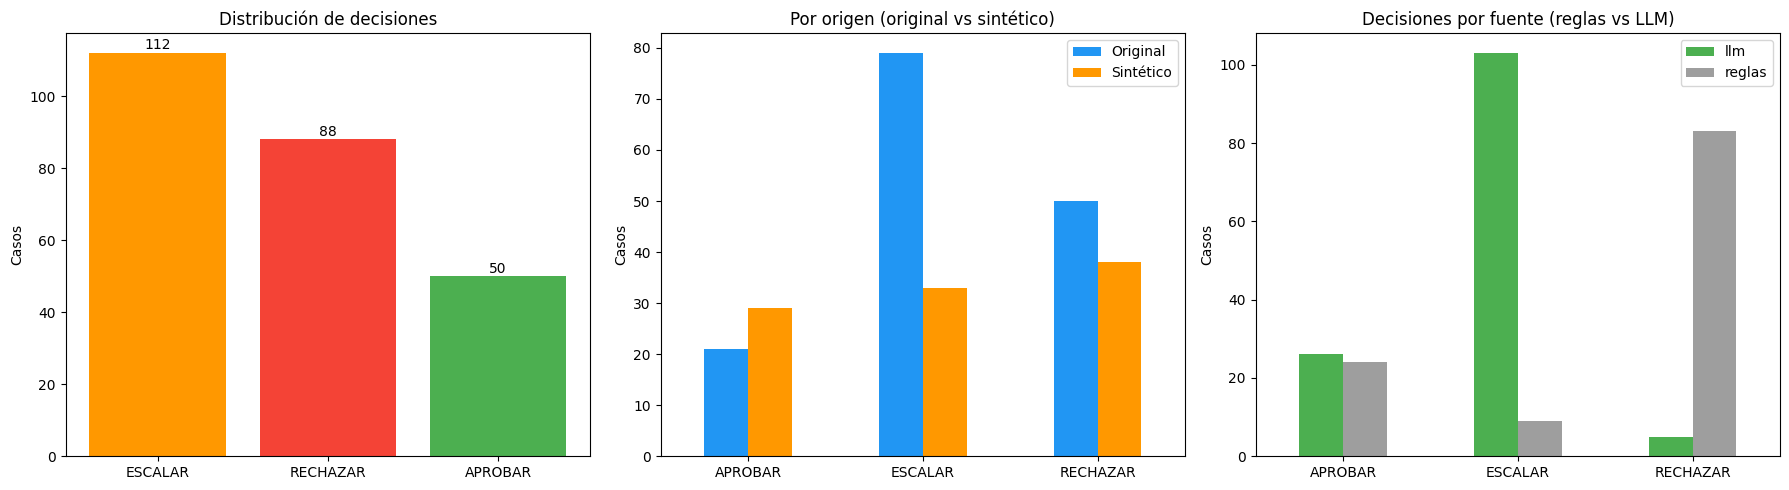

In [8]:
import matplotlib.pyplot as plt

# Consultar distribución actual de la DB
conn = db_conectar()
try:
    with conn.cursor() as cur:
        cur.execute("SELECT decision, COUNT(*) AS n FROM resolution_case GROUP BY decision ORDER BY n DESC")
        dist_rows = cur.fetchall()
        cur.execute("SELECT c.es_sintetico, a.decision, COUNT(*) AS n FROM casos c JOIN resolution_case a ON a.caso_id = c.caso_id GROUP BY c.es_sintetico, a.decision ORDER BY 1, 3 DESC")
        origen_rows = cur.fetchall()
        cur.execute("SELECT fuente, decision, COUNT(*) AS n FROM resolution_case GROUP BY fuente, decision ORDER BY fuente, decision")
        conf_rows = cur.fetchall()
    conn.close()
except:
    dist_rows = origen_rows = conf_rows = []

# Gráficos
if dist_rows:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    colors = {'APROBAR': '#4CAF50', 'RECHAZAR': '#F44336', 'ESCALAR': '#FF9800'}

    # 1. Distribución
    ax = axes[0]
    labels = [r[0] for r in dist_rows]
    values = [r[1] for r in dist_rows]
    ax.bar(labels, values, color=[colors.get(x, '#999') for x in labels])
    ax.set_title('Distribución de decisiones')
    ax.set_ylabel('Casos')
    for j, v in enumerate(values):
        ax.text(j, v + 1, str(v), ha='center')

    # 2. Por origen
    ax = axes[1]
    if origen_rows:
        df_orig = pd.DataFrame(origen_rows, columns=['sintetico', 'decision', 'n'])
        pivot = df_orig.pivot(index='decision', columns='sintetico', values='n').fillna(0)
        pivot.plot(kind='bar', ax=ax, color=['#2196F3', '#FF9800'])
        ax.set_title('Por origen (original vs sintético)')
        ax.set_ylabel('Casos')
        ax.set_xlabel('')
        ax.legend(['Original', 'Sintético'])
        ax.tick_params(axis='x', rotation=0)

    # 3. Decisiones por fuente (reglas vs LLM)
    ax = axes[2]
    if conf_rows:
        df_conf = pd.DataFrame(conf_rows, columns=['fuente', 'decision', 'n'])
        pivot_c = df_conf.pivot(index='decision', columns='fuente', values='n').fillna(0)
        pivot_c.plot(kind='bar', ax=ax, color=['#4CAF50', '#9E9E9E'])
        ax.set_title('Decisiones por fuente (reglas vs LLM)')
        ax.set_ylabel('Casos')
        ax.set_xlabel('')
        ax.legend(pivot_c.columns)
        ax.tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()
else:
    print('[INFO] DB no disponible para visualización.')

## Análisis de casos con LLM

Casos donde el LLM produjo análisis estructurado (resumen, veredicto, señales).

In [9]:
conn = db_conectar()
try:
    with conn.cursor() as cur:
        cur.execute("SELECT c.caso_id, a.decision, a.fuente, a.llm_resultado FROM casos c JOIN resolution_case a ON a.caso_id = c.caso_id WHERE a.llm_resultado IS NOT NULL ORDER BY c.caso_id")
        rows = cur.fetchall()
    conn.close()
except:
    rows = []

if rows:
    df_llm = pd.DataFrame(rows, columns=['caso_id', 'decision', 'fuente', 'llm_resultado'])
    print(f'Casos con análisis LLM: {len(df_llm)}')
    print(f'\nDistribución de decisiones (casos LLM):')
    print(df_llm['decision'].value_counts().to_string())
    print(f'\n--- Ejemplos de análisis LLM ---')
    for _, r in df_llm.head(2).iterrows():
        print(f'\nCaso {r["caso_id"]}: {r["decision"]} (fuente: {r.get("fuente", "")})')
        lr = r['llm_resultado']
        if lr:
            print(f'  resumen: {lr.get("resumen", "N/A")}')
            print(f'  veredicto: {lr.get("veredicto", "N/A")}')
            for s in lr.get('señales_explicadas', []):
                print(f'    • {s.get("señal", "")}: {s.get("explicacion", "")} (peso: {s.get("peso", "")})')
else:
    print('[INFO] No hay casos con análisis LLM en la DB.')
    print('Ejecuta procesar_batch() con OVERWRITE=True para generarlos.')

Casos con análisis LLM: 134

Distribución de decisiones (casos LLM):
decision
ESCALAR     103
APROBAR      26
RECHAZAR      5

--- Ejemplos de análisis LLM ---

Caso COMP-0001: APROBAR (fuente: llm)
  resumen: Reclamo estándar de pedido equivocado en cuenta antigua y sana, sin indicadores de abuso.
  veredicto: APROBAR: reclamo consistente con perfil de usuario confiable y sin señales de fraude.
    • Perfil de usuario confiable: antiguedad=1590d, 0 flags fraude, comp_ratio=0.63 (peso: alto)
    • Sin inconsistencia GPS: GPS no confirmada, no existe evidencia que contradiga el reporte (peso: medio)
    • Señal de ambigüedad: Sistema marca ambiguo pero el contexto histórico y operativo respalda la aprobación (peso: bajo)

Caso COMP-0002: ESCALAR (fuente: llm)
  resumen: Reclamo por alergia alimentaria con palabra crítica detectada. GPS parcial y historial con 1 flag no invalidan la necesidad de revisión especializada.
  veredicto: ESCALAR: contiene la palabra crítica 'alergia' que requi

## Verificación de integridad

Confirma que todos los casos procesados tienen decisión, justificación y señales.

In [ ]:
conn = db_conectar()
try:
    with conn.cursor() as cur:
        cur.execute("""SELECT COUNT(*) AS total,
                          COUNT(a.decision) AS con_decision,
                          COUNT(a.justificacion_regla) + COUNT(a.justificacion_llm) AS con_just,
                          COUNT(a.senales_regla) + COUNT(a.senales_llm) AS con_senales
                   FROM cases c LEFT JOIN resolution_case a ON a.caso_id = c.caso_id
        """)
        row = cur.fetchone()
    conn.close()
except:
    row = (0, 0, 0, 0)

total, con_dec, con_just, con_senales = row
print(f'Total casos:          {total}')
print(f'Con decisión:         {con_dec}')
print(f'Con justificación:    {con_just}')
print(f'Con señales:          {con_senales}')
print()
if total > 0:
    assert con_dec == total, f'{total - con_dec} casos sin decisión'
    assert con_just >= total, f'{total - con_just} casos sin justificación'
    assert con_senales >= total, f'{total - con_senales} casos sin señales'
    print('[OK] Verificación superada: todos los casos tienen decisión + justificación + señales.')
else:
    print('[SKIP] DB no disponible.')


## Conclusiones

- **Pipeline inline:** el código de los 6 nodos está en esta notebook, editable en caliente.
- **Flags interactivos:** `OVERWRITE`, `SAVE_TO_DB`, `USE_DB_RULES` controlan el comportamiento.
- **Batch con control:** `procesar_batch()` salta casos ya analizados si `OVERWRITE=False`.
- **Análisis individual:** `await analizar_caso('COMP-XXXX')` muestra el detalle completo.
- **Verificación:** assertions confirman que todos los casos tienen decisión + justificación + señales.

> **Nota:** Para reprocesar todos los casos, cambiar `OVERWRITE = True` en la celda de
> Setup y ejecutar `await procesar_batch()`. El LLM puede tardar ~15s por caso ambiguo (async).